In [1]:
from transformers import GPT2LMHeadModel

## exploring the GPT-2 (124M) OpenAI checkpoint

- original GPT-2 code is TensorFlow; HuggingFace ported it to PyTorch - use HF, not the original repo
- `"gpt2"` = 124M (the small one); `"gpt2-xl"` = 1.5B - confusing naming, easy to get wrong
- state dict = the full model as a dict of named tensors; inspecting it tells you the entire architecture
- `wte.weight [50257, 768]` - lookup table: each of the 50257 BPE tokens maps to a 768-dim vector
  - takeaway: a token is just an index; this table is how it becomes a meaningful vector
- `wpe.weight [1024, 768]` - same idea but for positions; GPT-2 max context = 1024 tokens
  - takeaway: position is not baked into the architecture, it is a learned parameter like any other weight
- 12 blocks `h.0` to `h.11`; each block has layer norms, attn (c_attn, c_proj), mlp (c_fc, c_proj)
  - takeaway: the state dict keys are a map of the model - you can reconstruct the architecture just from the key names and shapes

In [2]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")  ## 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

In [4]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

torch.Size([50257, 768])
torch.Size([50257, 768])
14122889171
14122889171


In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

## visualization notes

- `wpe` heatmap `[1024, 768]`: each row = one position; the visible banded structure means nearby positions have similar representations
- individual channels show sinusoidal-looking curves across positions
  - takeaway: the model learned to use frequency-based position encoding on its own, just from next-token prediction - nobody told it to
- original Transformer paper (Attention is All You Need) used fixed sinusoids for position; GPT-2 just makes them trainable params and gets the same result
  - takeaway: learned vs fixed positional encodings does not matter much in practice
- jagged/noisy curves = undertrained checkpoint; smoother = more training
  - takeaway: you can eyeball weight plots to get a rough sense of training quality
- `attn.c_attn.weight[:300, :300]` shows block structure
  - takeaway: structure in weight matrices is real and interpretable, not random noise - active area of research (mechanistic interpretability)

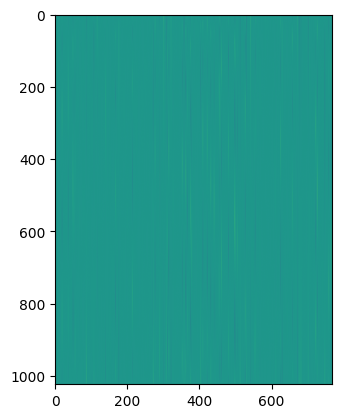

In [6]:
plt.imshow(sd_hf["transformer.wpe.weight"])

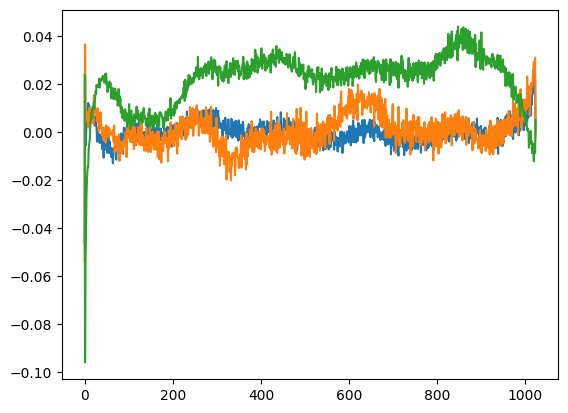

In [7]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

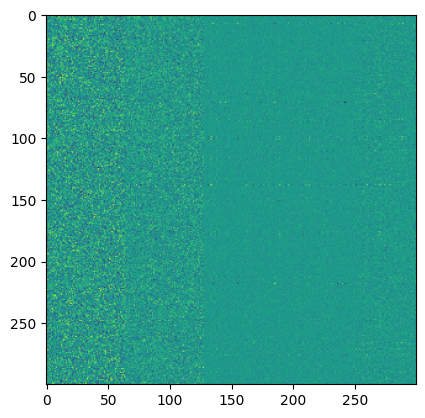

In [8]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300, :300])

In [9]:
from transformers import pipeline, set_seed

In [10]:
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "Hello, I'm a language model, and my project will get better with time, but I think there are a lot more things that can help you"},
 {'generated_text': "Hello, I'm a language model, not a language model, so if I don't have a problem, I can fix it by creating new words"},
 {'generated_text': "Hello, I'm a language model, and I'm trying to learn some stuff. I'll try to do some basic programming and just learn better ways"},
 {'generated_text': "Hello, I'm a language model, but I don't believe in grammar. This will work for every language model. You can define it very quickly"},
 {'generated_text': 'Hello, I\'m a language model, a model of how things should be, and then we look at different things as well." I\'d like to'}]

In [11]:
import torch
import torch.nn.functional as F

In [12]:
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()
torch.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11]
tokens = torch.tensor(tokens, dtype=torch.long)
x = tokens.unsqueeze(0).repeat(5, 1)

while x.size(1) < 30:
    with torch.no_grad():
        logits = model(x)[0]
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)

        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        ix = torch.multinomial(topk_probs, num_samples=1)
        xcol = torch.gather(topk_indices, -1, ix)
        x = torch.cat((x, xcol), dim=1)

In [13]:
import tiktoken

In [14]:
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print("> ", decoded)

>  Hello, I'm a language model, not a science. I'm a language designer. I want to write, I want to think. I want
>  Hello, I'm a language model, I use an English sentence structure, I like words over sentences.

"That's OK I'll look
>  Hello, I'm a language model, not just another language." This isn't a "language model?" It's an idea. So far, what
>  Hello, I'm a language model, not a programming model. I'm not a theoretical computer model - you read that right - because my ideas are
>  Hello, I'm a language model, I teach myself.

I want to know more about how languages work and why they could be used.


In [15]:
with open('./dataset/input.txt', 'r') as f:
    text = f.read()

print(text[:100])


First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You
